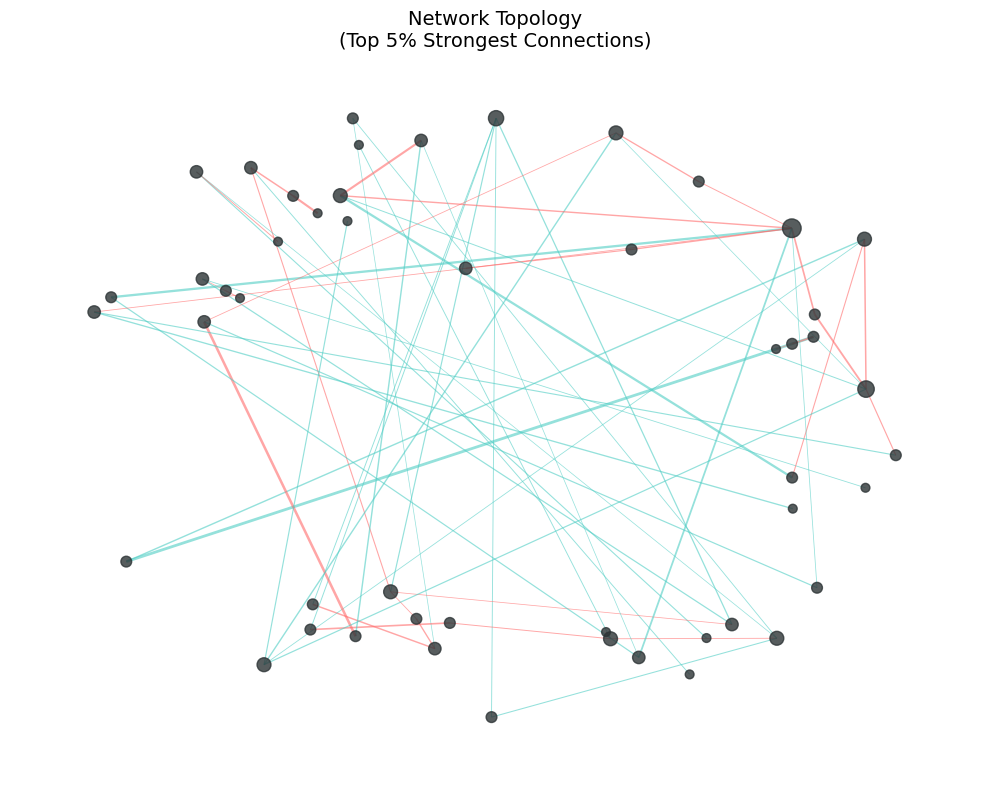

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def visualize_network_structure(W_matrix, threshold_percentile=90, title="Network Topology"):
    """
    Visualizes the W matrix using a force-directed layout.
    
    Args:
        W_matrix: Adjacency or Weight Matrix (N x N).
        threshold_percentile: Only show edges stronger than this percentile (e.g., 90 = Top 10%).
    """
    plt.figure(figsize=(10, 8))
    
    # 1. Data Preparation (Thresholding)
    # We work with absolute weights to determine "strength"
    W_abs = np.abs(W_matrix)
    np.fill_diagonal(W_abs, 0) # Ignore self-loops for layout
    
    # Determine threshold value
    threshold_val = np.percentile(W_abs, threshold_percentile)
    
    # Create Graph
    G = nx.Graph()
    N = W_matrix.shape[0]
    G.add_nodes_from(range(N))
    
    edges_to_add = []
    weights = []
    colors = []
    
    rows, cols = np.where(W_abs >= threshold_val)
    for r, c in zip(rows, cols):
        if r < c: # Undirected, process upper triangle only
            weight = W_matrix[r, c]
            G.add_edge(r, c, weight=weight)
            weights.append(abs(weight))
            # Color: Red for Positive, Blue for Negative
            colors.append('#ff6b6b' if weight > 0 else '#4ecdc4')

    # 2. Layout Calculation (The Physics)
    # k parameter controls node spacing (larger = more spread out)
    pos = nx.spring_layout(G, seed=42, k=0.5/np.sqrt(N), iterations=50)
    
    # 3. Node Styling (Hubs are bigger)
    # Calculate degree based on thresholded graph
    d = dict(G.degree)
    node_sizes = [v * 20 + 20 for v in d.values()]
    
    # 4. Draw
    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#2d3436', alpha=0.8)
    
    # Draw Edges (Width scaled by weight)
    # Normalize weights for display width (0.5 to 2.0)
    if weights:
        w_min, w_max = min(weights), max(weights)
        widths = [0.5 + 1.5 * (w - w_min) / (w_max - w_min + 1e-9) for w in weights]
        nx.draw_networkx_edges(G, pos, width=widths, edge_color=colors, alpha=0.6)
    
    # Labels (Optional: Only label Hubs)
    # nx.draw_networkx_labels(G, pos, font_size=8, font_color='white')

    plt.title(f"{title}\n(Top {100-threshold_percentile}% Strongest Connections)", fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# --- Usage Example ---
if __name__ == "__main__":
    # Generate a synthetic Modular Network
    N = 50
    # Create block diagonal structure (2 communities)
    c1 = np.random.randn(25, 25) * 2.0
    c2 = np.random.randn(25, 25) * 2.0
    noise = np.random.randn(50, 50) * 0.2
    
    W_synth = noise
    W_synth[:25, :25] += c1
    W_synth[25:, 25:] += c2
    
    # Symmetrize
    W_synth = (W_synth + W_synth.T) / 2
    
    visualize_network_structure(W_synth, threshold_percentile=95)
